# ANIMEGAN BENCHMARK 

AnimeGAN Benchmark (Standalone)
Using device: cuda

--- Loading AnimeGAN Models ---
Loading 'paprika'...


Using cache found in C:\Users\ASUS/.cache\torch\hub\bryandlee_animegan2-pytorch_main


  ✓ Loaded on cuda
Loading 'face_paint_v2'...
  ✓ Loaded on cuda
Loading 'celeba_distill'...


Using cache found in C:\Users\ASUS/.cache\torch\hub\bryandlee_animegan2-pytorch_main
Using cache found in C:\Users\ASUS/.cache\torch\hub\bryandlee_animegan2-pytorch_main


  ✓ Loaded on cuda

✓ Loaded 3 models

--- Running Inference ---

Processing 'paprika'...
  Time: 1.76s
  ✓ Saved

Processing 'face_paint_v2'...
  Time: 0.00s
  ✓ Saved

Processing 'celeba_distill'...
  Time: 0.01s
  ✓ Saved

✓ Inference complete!

--- Displaying Results ---


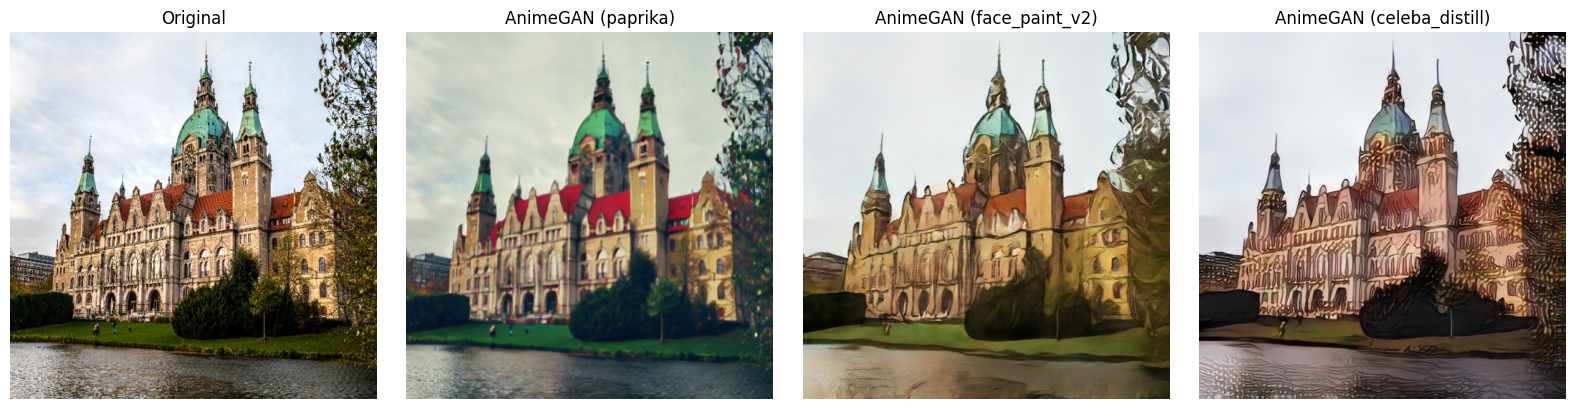


✓ Results saved to results_animegan_benchmark/


In [1]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
import time
import cv2
from skimage.metrics import structural_similarity as ssim

print("="*60)
print("AnimeGAN Benchmark (Standalone)")
print("="*60)

# Check device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Create output directory
output_dir = 'results_animegan_benchmark'
os.makedirs(output_dir, exist_ok=True)

# ==============================================================================
# LOAD MODELS
# ==============================================================================

print("\n--- Loading AnimeGAN Models ---")

models = {}

for name, pretrained in [('paprika', 'paprika'), 
                          ('face_paint_v2', 'face_paint_512_v2'),
                          ('celeba_distill', 'celeba_distill')]:
    try:
        print(f"Loading '{name}'...")
        models[name] = torch.hub.load(
            "bryandlee/animegan2-pytorch:main",
            "generator",
            pretrained=pretrained,
            trust_repo=True
        ).eval().to(device)
        print(f"  ✓ Loaded on {device}")
    except Exception as e:
        print(f"  ✗ Failed: {e}")

print(f"\n✓ Loaded {len(models)} models")

# ==============================================================================
# IMAGE PROCESSING
# ==============================================================================

def load_image(image_path, size=512):
    img = Image.open(image_path).convert("RGB")
    img = img.resize((size, size), Image.LANCZOS)
    
    img_tensor = torch.from_numpy(np.array(img)).permute(2, 0, 1).unsqueeze(0).float()
    img_tensor = (img_tensor / 127.5 - 1.0).to(device)
    
    return img_tensor, img

def postprocess(output_tensor):
    output = output_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
    output = ((output + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
    return Image.fromarray(output)

# ==============================================================================
# RUN INFERENCE
# ==============================================================================

print("\n--- Running Inference ---")

content_path = 'ContentImage_512x512.jpg'

if os.path.exists(content_path):
    img_tensor, original_img = load_image(content_path)
    original_img.save(os.path.join(output_dir, 'original.jpg'))
    
    results = {}
    
    for name, model in models.items():
        print(f"\nProcessing '{name}'...")
        
        start = time.time()
        with torch.no_grad():
            output = model(img_tensor)
        elapsed = time.time() - start
        
        print(f"  Time: {elapsed:.2f}s")
        
        result_img = postprocess(output)
        result_img.save(os.path.join(output_dir, f'animegan_{name}.jpg'))
        print(f"  ✓ Saved")
        
        results[name] = np.array(result_img)
    
    print("\n✓ Inference complete!")
else:
    print(f"ERROR: {content_path} not found")

# ==============================================================================
# DISPLAY RESULTS
# ==============================================================================

print("\n--- Displaying Results ---")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(original_img)
axes[0].set_title('Original')
axes[0].axis('off')

for idx, (name, img_array) in enumerate(results.items()):
    axes[idx+1].imshow(img_array)
    axes[idx+1].set_title(f'AnimeGAN ({name})')
    axes[idx+1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'animegan_results.jpg'), dpi=150)
plt.show()

print(f"\n✓ Results saved to {output_dir}/")

In [3]:
import torch
from PIL import Image
import torchvision.transforms as transforms
import os

# Load model
model = torch.hub.load('bryandlee/animegan2-pytorch', 'generator', pretrained='paprika')
model.eval()
model = model.cuda()  # Use GPU if available

# Define transform
transform = transforms.Compose([
    transforms.ToTensor()
])

# Process video frames
input_dir = 'video_frames_input'
output_dir = 'video_frames_animegan'
os.makedirs(output_dir, exist_ok=True)

frame_files = sorted([f for f in os.listdir(input_dir) if f.endswith('.png')])

for i, frame_file in enumerate(frame_files):
    # Load frame as PIL Image
    img = Image.open(os.path.join(input_dir, frame_file)).convert('RGB')
    
    # Convert to tensor [0, 1] -> [-1, 1]
    img_tensor = transform(img).unsqueeze(0)  # Add batch dimension
    img_tensor = img_tensor * 2 - 1  # Scale to [-1, 1]
    img_tensor = img_tensor.cuda()  # Move to GPU
    
    # Process with AnimeGAN
    with torch.no_grad():
        output = model(img_tensor)
    
    # Convert back to image
    output = output.cpu().squeeze(0)  # Remove batch dimension
    output = (output + 1) / 2  # Scale back to [0, 1]
    output = output.clamp(0, 1)
    
    # Save
    output_img = transforms.ToPILImage()(output)
    output_img.save(os.path.join(output_dir, frame_file))
    
    if i % 30 == 0:
        print(f"Processed {i+1}/{len(frame_files)}")

print(" AnimeGAN processing complete!")



Using cache found in C:\Users\ASUS/.cache\torch\hub\bryandlee_animegan2-pytorch_main


Processed 1/192
Processed 31/192
Processed 61/192
Processed 91/192
Processed 121/192
Processed 151/192
Processed 181/192
 AnimeGAN processing complete!


In [4]:
import cv2
import os

def frames_to_video(frames_dir, output_path, fps=30):
    """Combine frames into video."""
    frame_files = sorted([f for f in os.listdir(frames_dir) if f.endswith('.png')])
    
    if not frame_files:
        print(f"No frames found in {frames_dir}")
        return
    
    # Read first frame to get dimensions
    first_frame = cv2.imread(os.path.join(frames_dir, frame_files[0]))
    h, w = first_frame.shape[:2]
    
    # Create video writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(output_path, fourcc, fps, (w, h))
    
    for frame_file in frame_files:
        frame = cv2.imread(os.path.join(frames_dir, frame_file))
        writer.write(frame)
    
    writer.release()
    print(f"✓ Video saved: {output_path}")

# Create AnimeGAN video
frames_to_video('video_frames_animegan', 'video_results/animegan_output.mp4', fps=30)

✓ Video saved: video_results/animegan_output.mp4


In [5]:
# Compute Temporal Consistency for AnimeGAN
import numpy as np
import cv2
import os

def compute_temporal_consistency(frames_dir):
    """Compute temporal consistency (lower = less flickering)."""
    frame_files = sorted([f for f in os.listdir(frames_dir) if f.endswith('.png')])
    
    frame_diffs = []
    prev_frame = None
    
    for frame_file in frame_files:
        frame = cv2.imread(os.path.join(frames_dir, frame_file))
        frame = frame.astype(np.float32) / 255.0
        
        if prev_frame is not None:
            diff = np.mean(np.abs(frame - prev_frame))
            frame_diffs.append(diff)
        
        prev_frame = frame
    
    return {
        'mean_diff': np.mean(frame_diffs),
        'std_diff': np.std(frame_diffs),
        'max_diff': np.max(frame_diffs)
    }

# Compute for AnimeGAN
metrics_animegan = compute_temporal_consistency('video_frames_animegan')

print("AnimeGAN Temporal Consistency:")
print(f"  Mean frame diff: {metrics_animegan['mean_diff']:.4f}")
print(f"  Std frame diff:  {metrics_animegan['std_diff']:.4f}")
print(f"  Max frame diff:  {metrics_animegan['max_diff']:.4f}")

AnimeGAN Temporal Consistency:
  Mean frame diff: 0.0136
  Std frame diff:  0.0017
  Max frame diff:  0.0158


In [6]:
def compute_avg_flatness(frames_dir, sample_frames=10):
    """Compute average flatness score."""
    frame_files = sorted([f for f in os.listdir(frames_dir) if f.endswith('.png')])
    indices = np.linspace(0, len(frame_files)-1, sample_frames, dtype=int)
    
    flatness_scores = []
    for idx in indices:
        frame = cv2.imread(os.path.join(frames_dir, frame_files[idx]))
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        laplacian = cv2.Laplacian(gray, cv2.CV_64F)
        variance = laplacian.var()
        flatness = 1.0 / (1.0 + variance / 500.0)
        flatness_scores.append(flatness)
    
    return np.mean(flatness_scores)

flatness_animegan = compute_avg_flatness('video_frames_animegan')
print(f"AnimeGAN Flatness: {flatness_animegan:.4f}")

AnimeGAN Flatness: 0.7331
